Taller 1 
------------
Integrantes: Sebastian Perez, David Gomez , David Castro, Maria Isabel Collazos, Juan David Parra , David Ortigoza 


## Descripción del poblema e impacto
La endocarditis infecciosa es una enfermedad grave y de manejo complejo. En esta cohorte la mortalidad intrahospitalaria cruda fue de 19.9% (30/151 pacientes con desenlace registrado), el 76.8% de los pacientes requirió UCI (116/151) y la estancia hospitalaria promedio fue de 38.2 días (mediana 30.5). Hoy esas decisiones (traslado a UCI, cirugía temprana, ajuste de antibiótico) se toman con juicio clínico y escalas generales de diagnóstico (criterios de Duke), sin una herramienta que integre de forma sistemática las más de 100 variables clínicas, de laboratorio, microbiológicas y ecocardiográficas ya disponibles por paciente. El riesgo es un subtriage de pacientes de alto riesgo (que se beneficiarían de cirugía o UCI temprana) y un uso poco eficiente de camas críticas

La institución busca reducir al mínimo la mortalidad por endocarditis infecciosa mediante la identificación oportuna de pacientes de alto riesgo desde el momento de su admisión. Si bien la tasa de letalidad actual se encuentra dentro de los estándares de la literatura, el hospital carece de un sistema analítico que aproveche los datos clínicos disponibles al ingreso para cuantificar este riesgo de forma automatizada. Esta limitación afecta directamente el proceso de triaje y la toma de decisiones asistenciales en las áreas de urgencias, infectología y cuidados intensivos, impidiendo priorizar de manera proactiva el manejo intensivo en los casos con peor pronóstico. Superar esta brecha técnica optimizará el flujo asistencial y permitirá impactar directamente en el indicador clave de la organización: la Tasa de Mortalidad Intrahospitalaria por Endocarditis Infecciosa (KPI principal).

## Complejidad y disponibilidad de datos
Se cuenta con una base anonimizada de 152 pacientes × 216 variables, que incluye información demográfica, comorbilidades, cuadro clínico, signos vitales, laboratorios, hemocultivos/microbiología, hallazgos ecocardiográficos, complicaciones, manejo antibiótico y quirúrgico, estancia en UCI y desenlace. La base corresponde a casos de endocarditis atendidos en el hospital entre 2017 y 2022 y se actualiza mensualmente a partir de información de la historia clínica, imágenes diagnósticas y laboratorio, que posteriormente es digitada por profesionales de la salud, internos, estudiantes y digitadores. Esta metodología introduce cierta complejidad técnica por la integración de múltiples fuentes y posibles variaciones en los criterios de registro, por lo que será necesario realizar procesos de depuración y estandarización antes del modelamiento.

La calidad del dato es buena en general, con menos del 1% de faltantes en la mayoría de las variables clínicas y de laboratorio, excepto FEVI, que presenta 73% de faltantes y deberá ser imputada o excluida. Además, se deben descartar 12 casos con etiqueta "Remitido", debido a que no se conoce su desenlace clínico. La principal limitación es el tamaño muestral, con aproximadamente 30 eventos de muerte frente a 216 variables candidatas, lo que hace necesaria una selección cuidadosa de variables y una validación cruzada rigurosa para reducir el riesgo de sobreajuste.


## Justificación del uso de IA / Ciencia de Datos

La variable objetivo seleccionada es el estado vital al egreso (Vivo vs. Muerto), por ser el desenlace de mayor relevancia clínica y el que mejor se alinea con la pregunta SMART. El análisis exploratorio mostró que ninguna variable clínica o de laboratorio aislada (edad, creatinina, leucocitos, etc.) permite diferenciar adecuadamente entre pacientes que sobreviven y aquellos que fallecen. Esto evidencia que el pronóstico de mortalidad en endocarditis es multifactorial y depende de la combinación de variables clínicas, microbiológicas y ecocardiográficas.

Por esta razón, se utilizarán modelos de aprendizaje supervisado enfocados en la **clasificación de pacientes según su desenlace clínico (Vivo vs. Muerto)**. Entre estos se incluirá un modelo de **regresión logística**, que permitirá estimar la probabilidad individual de mortalidad e identificar las variables asociadas al desenlace mediante sus **odds ratio (OR)** e intervalos de confianza. Estos resultados permitirán complementar el componente predictivo con una interpretación clínica de los principales factores asociados a la mortalidad.

Se espera que esta estratificación permita identificar tempranamente a los pacientes de mayor riesgo, contribuyendo a reducir la mortalidad intrahospitalaria, cuya línea base es de 19,9%, y a optimizar el uso de camas UCI, considerando que el 76,8% de los pacientes requirió UCI, con una estancia media de 38,2 días.

El desempeño de los modelos se evaluará principalmente mediante **AUC-ROC (meta ≥0,80)**, sensibilidad, priorizando la identificación de pacientes que fallecerán, y un **valor predictivo negativo alto**. Finalmente, el impacto del proyecto se medirá durante un período piloto mediante la reducción porcentual de la mortalidad y de los días de estancia potencialmente evitables.


# Pegunta SMART
¿Puede un modelo de clasificación supervisada — con máximo 3 predictores (regla EPV: 30 eventos ÷ 10), entrenado y validado mediante validación cruzada estratificada sobre variables clínicas, de laboratorio, microbiológicas y ecocardiográficas de ingreso en pacientes con endocarditis infecciosa (2017–2022) — predecir la mortalidad intrahospitalaria (Vivo vs. Muerto) con un AUC-ROC ≥ 0.80 (con intervalo de confianza) y sensibilidad ≥ 0.70, en un periodo de 6 meses despues de la validación academica del modelo.

Especifico (S): Especifica el algoritmo (clasificación supervisada), las variables de entrada (datos de admisión) y el evento a predecir (mortalidad intrahospitalaria).

Medible (M): Establece umbrales cuantitativos exactos de desempeño (AUC-ROC >= 0.80 y Sensibilidad >= 0.70).

Alcanzable (A): Emplea datos recolectados de manera rutinaria durante la admisión institucional.

Relevante (R): Apunta directamente a la estratificación del riesgo para tomar decisiones oportunas y reducir la letalidad.

Temporal / Delimitado (T): Delimita la evaluación a la cohorte del hospital y la enmarca formalmente dentro del conjunto de validación del proyecto.

# Hipótesis de trabajo - Proyecto Endocarditis Infecciosa

Fase CRISP-DM: 2 (Data Understanding), como insumo para la Fase 4 (Modeling)
Grupo 1 - Cardiología e infectología

## Contexto

Con 152 pacientes y solo 30 desenlaces de mortalidad intrahospitalaria (30 eventos
frente a 216 variables candidatas en la base), la regla practica de "eventos por
variable" (EPV >= 10) limita a un maximo de ~3 predictores para un modelo
confirmatorio interpretable (regresion logistica clasica). Por eso, en lugar de
evaluar las 216 variables, se priorizaron 3 con criterio clinico, cubriendo tres
dominios distintos y no redundantes entre si.

Nota de limitacion: la literatura de referencia (estudio 2025, n=1705) identifica la
bilirrubina total como el predictor mas relevante de mortalidad en endocarditis.
Esa variable no esta disponible en esta base de 216 columnas, por lo que el modelo
debe apoyarse en variables proxy.

## Hipotesis general (alineada con la pregunta SMART del grupo)

Un modelo de clasificacion multivariado (regresion logistica regularizada o Random
Forest), entrenado con variables clinicas priorizadas por criterio clinico, permite
predecir la mortalidad intrahospitalaria (Vivo vs. Muerto) de pacientes con
endocarditis infecciosa, e identificar el peso relativo de cada variable en ese
desenlace, ajustando por las demas.

## Hipotesis especificas

| # | Dominio clinico | Variable(s) en la base | H0 (hipotesis nula) | H1 (hipotesis alterna) |
|---|---|---|---|---|
| H1 | Disfuncion cardiaca estructural | `Falla cardiaca`, `FEVI` | La presencia de falla cardiaca / FEVI reducida al ingreso no se asocia con la mortalidad intrahospitalaria | La presencia de falla cardiaca / FEVI reducida al ingreso se asocia con mayor mortalidad intrahospitalaria |
| H2 | Virulencia microbiologica | `Staphylococcus aureus` | La infeccion por *S. aureus* no se asocia con la mortalidad intrahospitalaria | La infeccion por *S. aureus* se asocia con mayor mortalidad intrahospitalaria, en comparacion con otros germenes |
| H3 | Reserva fisiologica del paciente | `Edad` | La edad del paciente no se asocia con la mortalidad intrahospitalaria | A mayor edad, mayor probabilidad de mortalidad intrahospitalaria |

## Variables excluidas del modelo confirmatorio (justificacion)

- **Shock septico / Sepsis Shock Septico**: descartada del set confirmatorio por
  posible circularidad temporal -- suele presentarse muy cerca del desenlace, lo
  que limita su utilidad como predictor temprano y accionable (el objetivo del
  proyecto es anticipar la decision de UCI/cirugia, no confirmar gravedad ya
  instaurada).
- **Complicaciones embolicas/neurologicas, marcadores inflamatorios/renales,
  tipo de endocarditis**: quedan como candidatas para un ejercicio exploratorio
  posterior (Random Forest / LASSO con mayor numero de variables), no como parte
  de la hipotesis confirmatoria de 3 variables.

## Nota de metodo (sesgo por indicacion)

La variable `Intervencion quirurgica` se considero y se dejo fuera intencionalmente
del set confirmatorio: en la practica clinica, van a cirugia los pacientes que ya
fallaron a manejo medico, por lo que una asociacion cruda entre cirugia y
mortalidad puede reflejar la gravedad basal del paciente (variable de confusion),
no un efecto causal de la cirugia en si. Si se incluye en analisis futuros, debe
ajustarse explicitamente por gravedad al ingreso.

## Referencia cruzada con el diccionario de datos

Las 3 variables de las hipotesis especificas y su tipo propuesto, segun
`diccionario_datos.csv`:

| variable | tipo_propuesto | pct_nulos |
|---|---|---|
| Falla cardiaca | categorica binaria | 0.0 |
| FEVI | categorica nominal | 73.0 (revisar imputacion en Fase 3) |
| Staphylococcus aureus | categorica nominal | 0.7 |
| Edad | numerica | 0.0 |


# Diccionario de datos - Base Endocarditis

Filas: 152 | Columnas: 216

| variable                                                      | tipo_propuesto                      |   pct_nulos |   n_valores_unicos | ejemplos_valores                                             | observaciones_calidad                                                                                                                 |
|:--------------------------------------------------------------|:------------------------------------|------------:|-------------------:|:-------------------------------------------------------------|:--------------------------------------------------------------------------------------------------------------------------------------|
| ID                                                            | numerica                            |         0   |                152 | 1, 2, 3, 4, 5                                                |                                                                                                                                       |
| Edad                                                          | numerica                            |         0   |                 67 | 60, 75, 2, 62, 72                                            |                                                                                                                                       |
| Sexo                                                          | categorica binaria                  |         0   |                  2 | Hombre, Mujer                                                |                                                                                                                                       |
| Fecha de ingreso                                              | fecha (almacenada como texto)       |         0   |                144 | 25/10/22, 13/12/16, 15/02/17, 30/12/16, 20/01/17             | Convertir a tipo fecha en fase de preparacion de datos                                                                                |
| Fecha de egreso                                               | fecha (almacenada como texto)       |         0   |                147 | 18/11/22, 29/11/22, 22/03/17, 17/04/17, 9/02/17              | Convertir a tipo fecha en fase de preparacion de datos                                                                                |
| Dias estancia                                                 | numerica                            |         0   |                 71 | 24, 35, 99, 61, 41                                           |                                                                                                                                       |
| Hipertension arterial                                         | categorica binaria                  |         0   |                  2 | No, Si                                                       |                                                                                                                                       |
| Diabetes mellitus                                             | categorica binaria                  |         0   |                  2 | No, Si                                                       |                                                                                                                                       |
| Dislipidemia                                                  | categorica binaria                  |         0   |                  2 | No, Si                                                       |                                                                                                                                       |
| Obesidad Sobrepeso                                            | categorica nominal                  |         0   |                  3 | No, Sobrepeso (>=25-29.9 IMC), Obesidad (>=30 IMC)           |                                                                                                                                       |
| Falla cardiaca                                                | categorica binaria                  |         0   |                  2 | No, Si                                                       |                                                                                                                                       |
| FEVI                                                          | categorica nominal                  |        73   |                  3 | < 40%, > o igual 50%, 40-49%                                 |                                                                                                                                       |
| Fibrilacion auricular                                         | categorica binaria                  |         0   |                  2 | No, Si                                                       |                                                                                                                                       |
| Enfermedad coronaria                                          | categorica nominal                  |         0   |                  3 | No, Si, No information                                       | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Accidente cerebrovascular                                     | categorica binaria                  |         0   |                  2 | No, Si                                                       |                                                                                                                                       |
| Valvulopatia                                                  | categorica binaria                  |         0   |                  2 | No, Si                                                       |                                                                                                                                       |
| Estenosis valvular Ninguna                                    | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Estenosis valvular Tricuspide                                 | categorica nominal                  |         0   |                  1 | No seleccionados                                             |                                                                                                                                       |
| Estenosis valvular Aortica                                    | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Estenosis valvular Pulmonar                                   | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Estenosis valvular Mitral                                     | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Estenosis valvular No information                             | categorica nominal                  |         0   |                  1 | No seleccionados                                             |                                                                                                                                       |
| Insuficiencia valvular Ninguna                                | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Insuficiencia valvular Tricuspide                             | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Insuficiencia valvular Aortica                                | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Insuficiencia valvular Pulmonar                               | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Insuficiencia valvular Mitral                                 | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Insuficiencia valvular No information                         | categorica nominal                  |         0   |                  1 | No seleccionados                                             |                                                                                                                                       |
| Reemplazo valvular                                            | categorica binaria                  |        67.8 |                  2 | Si, No                                                       |                                                                                                                                       |
| Reemplazo valvular mecanico                                   | categorica nominal                  |        77.6 |                  3 | No Aplica, Aortica, Mitral                                   |                                                                                                                                       |
| Reemplazo valvular biologica                                  | categorica nominal                  |        77.6 |                  5 | Mitral, Aortica, Pulmonar, Tricuspide, No aplica             |                                                                                                                                       |
| Cirugia cardiaca no valvular                                  | categorica binaria                  |         0   |                  2 | No, Si                                                       |                                                                                                                                       |
| Dispositivo cardiaco No                                       | categorica binaria                  |         0   |                  2 | Seleccionados, No seleccionados                              |                                                                                                                                       |
| Dispositivo cardiaco CDI                                      | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Dispositivo cardiaco TRC                                      | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Dispositivo cardiaco Marcapasos                               | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Dispositivo cardiaco No information                           | categorica nominal                  |         0   |                  1 | No seleccionados                                             |                                                                                                                                       |
| Enfermedad cardiaca reumatica                                 | categorica binaria                  |         0   |                  2 | No, Si                                                       |                                                                                                                                       |
| Abuso de alcohol                                              | categorica nominal                  |         0   |                  3 | No, Si, No information                                       | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Cancer                                                        | categorica binaria                  |         0   |                  2 | No, Si                                                       |                                                                                                                                       |
| Inmunosupresion o enfermedad autoinmune No                    | categorica binaria                  |         0   |                  2 | Seleccionados, No seleccionados                              |                                                                                                                                       |
| Inmunosupresion o enfermedad autoinmune Trasplantado          | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Inmunosupresion o enfermedad autoinmune Enfermedad autoinmune | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Inmunosupresion o enfermedad autoinmune Uso de esteroides     | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Inmunosupresion o enfermedad autoinmune VIH                   | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Inmunosupresion o enfermedad autoinmune Otro                  | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Inmunosupresion o enfermedad autoinmune No information        | categorica nominal                  |         0   |                  1 | No seleccionados                                             |                                                                                                                                       |
| Enfermedad hepatica cirrosis                                  | categorica binaria                  |         0   |                  2 | No, Si                                                       |                                                                                                                                       |
| Enfermedad renal                                              | categorica nominal                  |         0   |                  4 | No, Si, con hemodialisis, Si, sin dialisis, Si, con dialisis |                                                                                                                                       |
| Enfermedad pulmonar obstructiva cronica                       | categorica binaria                  |         0   |                  2 | No, Si                                                       |                                                                                                                                       |
| Enfermedad tiroidea                                           | categorica nominal                  |         0   |                  3 | No, Hipotiroidismo, Hipertiroidismo                          |                                                                                                                                       |
| Cardiopatia congenita                                         | categorica binaria                  |         0   |                  2 | Si, No                                                       |                                                                                                                                       |
| Cateter permanente                                            | categorica binaria                  |         0   |                  2 | No, Si                                                       |                                                                                                                                       |
| Cirugia o procedimiento endoscopico previo                    | categorica nominal                  |         0   |                  4 | No, Gastrointestinal, Urologico, No information              | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Endocarditis previa                                           | categorica binaria                  |         0   |                  2 | No, Si                                                       |                                                                                                                                       |
| Procedimiento odontologico previo                             | categorica binaria                  |         0   |                  2 | No, Si                                                       |                                                                                                                                       |
| Presencia de inflamacion infeccion odontologica               | categorica nominal                  |         1.3 |                  3 | No information, No, Si                                       | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Uso de drogas IV                                              | categorica nominal                  |         0.7 |                  3 | No, Si, No information                                       | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Otro factor predisponente                                     | texto libre / otro                  |         2   |                 48 | infeccion urinaria y artritis septica, No information, Vacun | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Fecha de inicio de los sintomas                               | fecha (almacenada como texto)       |         0   |                142 | 21/09/22, 13/10/22, 10/11/16, 15/02/17, 30/12/16             | Convertir a tipo fecha en fase de preparacion de datos; Contiene 'No information' como texto; tratar como nulo en fase de preparacion |
| Fiebre                                                        | categorica binaria                  |         0   |                  2 | No, Si                                                       |                                                                                                                                       |
| Disnea                                                        | categorica nominal                  |         0   |                  3 | Si, No, No information                                       | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Astenia adinamia                                              | categorica nominal                  |         0   |                  3 | Si, No, No information                                       | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Sintomas neurologicos                                         | categorica binaria                  |         0   |                  2 | No, Si                                                       |                                                                                                                                       |
| Tos                                                           | categorica nominal                  |         0   |                  3 | Si, No, No information                                       | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Eventos vasculares No                                         | categorica binaria                  |         0   |                  2 | Seleccionados, No seleccionados                              |                                                                                                                                       |
| Eventos vasculares Lesion de Janeway                          | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Eventos vasculares Hemorragia en astilla                      | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Eventos vasculares Embolismo                                  | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Eventos vasculares Hemorragia conjuntival                     | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Eventos vasculares ACV hemorragico                            | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Eventos vasculares ACV isquemico                              | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Eventos vasculares No information                             | categorica nominal                  |         0   |                  1 | No seleccionados                                             |                                                                                                                                       |
| Hematuria                                                     | categorica binaria                  |         0   |                  2 | No, Si                                                       |                                                                                                                                       |
| Manifestacion inmunologica No                                 | categorica binaria                  |         0   |                  2 | Seleccionados, No seleccionados                              |                                                                                                                                       |
| Manifestacion inmunologica Nodulo de Osler                    | categorica nominal                  |         0   |                  1 | No seleccionados                                             |                                                                                                                                       |
| Manifestacion inmunologica Manchas de Roth                    | categorica nominal                  |         0   |                  1 | No seleccionados                                             |                                                                                                                                       |
| Manifestacion inmunologica Glomerulonefritis                  | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Manifestacion inmunologica No information                     | categorica nominal                  |         0   |                  1 | No seleccionados                                             |                                                                                                                                       |
| Descompensacion de falla cardiaca                             | categorica nominal                  |         0   |                  6 | Stevenson B, No aplica, Stevenson A, No information, Stevens | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Sepsis Shock Septico                                          | categorica nominal                  |         0   |                  4 | No, Shock  septico, Sepsis, No information                   | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Peso                                                          | numerica (con placeholder de texto) |         0   |                 82 | 59,1, 62, 10, 52, 75                                         |                                                                                                                                       |
| Talla                                                         | numerica (con placeholder de texto) |         0   |                 46 | 169, 170, 85, 165, 160                                       | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| IMC                                                           | numerica (con placeholder de texto) |         0   |                115 | 20,7, 21,5, 13,8, 19,1, 29,3                                 | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Presion arterial sistolica                                    | numerica                            |         0   |                 76 | 150, 75, 94, 105, 147                                        |                                                                                                                                       |
| Presion arterial diastolica                                   | numerica                            |         0   |                 57 | 65, 37, 56, 62, 74                                           |                                                                                                                                       |
| Presion arterial media                                        | numerica (con placeholder de texto) |         0   |                 89 | 93, 49,67, 68, 76, 90                                        |                                                                                                                                       |
| Frecuencia cardiaca                                           | numerica                            |         0   |                 70 | 108, 110, 91, 104, 102                                       |                                                                                                                                       |
| Frecuencia respiratoria                                       | numerica                            |         0   |                 25 | 19, 26, 24, 16, 38                                           |                                                                                                                                       |
| Esplenomegalia                                                | categorica binaria                  |         0   |                  2 | No, Si                                                       |                                                                                                                                       |
| Hepatomegalia                                                 | categorica binaria                  |         0   |                  2 | No, Si                                                       |                                                                                                                                       |
| Soplo cardiaco de novo                                        | categorica binaria                  |         0   |                  2 | No, Si                                                       |                                                                                                                                       |
| Exacerbacion  soplo cardiaco preexistente                     | categorica binaria                  |         0   |                  2 | No, Si                                                       |                                                                                                                                       |
| Edema en miembros inferiores                                  | categorica binaria                  |         0   |                  2 | No, Si                                                       |                                                                                                                                       |
| Leucocitos                                                    | numerica                            |         0.7 |                146 | 9120.0, 10040.0, 8970.0, 9010.0, 19290.0                     |                                                                                                                                       |
| Linfocitos                                                    | numerica (con placeholder de texto) |         0.7 |                117 | 1210, 1060, 3100, 1530, 610                                  |                                                                                                                                       |
| Neutrofilos                                                   | numerica (con placeholder de texto) |         0.7 |                146 | 6840, 6930, 4280, 5750, 17880                                |                                                                                                                                       |
| Hemoglobina                                                   | numerica (con placeholder de texto) |         0.7 |                 72 | 11,4, 10,5, 9,3, 7,2, 11,2                                   |                                                                                                                                       |
| Plaquetas                                                     | numerica                            |         0.7 |                125 | 195000.0, 14600.0, 132000.0, 332000.0, 317000.0              |                                                                                                                                       |
| Velocidad eritrosedimentacion                                 | numerica (con placeholder de texto) |         0.7 |                 59 | 67, No information, 22, 31, 58                               | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Proteina C reactiva                                           | numerica (con placeholder de texto) |         0.7 |                146 | 9,7, 7,02, 2,31, 16,59, 47,6                                 | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Factor reumatoideo                                            | numerica (con placeholder de texto) |         0.7 |                 14 | No information, 246, 13,3, 45,9, 10                          | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Creatinina                                                    | numerica (con placeholder de texto) |         0.7 |                118 | 0,99, 0,69, 0,34, 0,85, 0,86                                 |                                                                                                                                       |
| Nitrogeno ureico                                              | numerica (con placeholder de texto) |         0.7 |                130 | 8,7, 17,3, 34, 18,9, 17,1                                    |                                                                                                                                       |
| NT proBNP BNP                                                 | numerica (con placeholder de texto) |         0.7 |                 52 | 1782, No information, 4206, 6651, 2823                       | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Troponina I ultrasensible                                     | numerica (con placeholder de texto) |         0.7 |                 50 | 188, No information, 24,1, 0,0053, 1000                      | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Troponina T                                                   | numerica (con placeholder de texto) |         0.7 |                  3 | No information, 47, 436                                      | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Procalcitonina                                                | numerica (con placeholder de texto) |         0.7 |                 31 | 0,062, No information, 5,78, 0,147, 1,08                     | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Potasio                                                       | numerica (con placeholder de texto) |         0.7 |                106 | 4,1, 3,3, 3,44, 4,33, 4,44                                   |                                                                                                                                       |
| Sodio                                                         | numerica (con placeholder de texto) |         0.7 |                 75 | 138, 135, 141, 136, 147                                      | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| AST                                                           | numerica (con placeholder de texto) |         0.7 |                129 | 11, No information, 435, 51,4, 40,3                          | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| ALT                                                           | numerica (con placeholder de texto) |         0.7 |                123 | 16, No information, 441, 64,5, 59,4                          | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Hemocultivo                                                   | categorica binaria                  |         0.7 |                  2 | Negativo, Positivo                                           |                                                                                                                                       |
| Staphylococcus aureus                                         | categorica nominal                  |         0.7 |                  4 | No, Si, meticilino sensible, Si, meticilino resistente, No i | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Staphylococcus coagulasa negativo                             | categorica nominal                  |         0.7 |                  8 | No, S. epidermidis, S. capitis, S. haemolyticus, S. hominis  | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Streptococcus                                                 | categorica nominal                  |         0.7 |                  7 | No, S. pneumoniae, S. viridans, S. gallolyticus  (bovis), S. | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Enterococcus spp                                              | categorica nominal                  |         0.7 |                  6 | No, E. faecalis, No information, E. faecium, E. gallinarum   | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| HACEK                                                         | categorica nominal                  |         0.7 |                  4 | No, Aggregatibacter spp, Haemophilus spp, No information     | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Bacteria gram negativa                                        | categorica nominal                  |         0.7 |                  7 | No, Serratia marcescens, Klebsiella spp, Pseudomonas spp, No | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Hongos                                                        | categorica nominal                  |         0.7 |                  3 | No, No information, Candida spp                              | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Polimicrobiano                                                | categorica nominal                  |         0.7 |                  3 | No, Si, No information                                       | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Otro patogeno                                                 | categorica nominal                  |         1.3 |                 12 | No information, Staphylococcushaemolyticus, Actinomycesdenti | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Aislamiento positivo                                          | categorica binaria                  |         1.3 |                  2 | No, Si                                                       |                                                                                                                                       |
| Ecocardiograma                                                | categorica nominal                  |         0.7 |                  1 | Si                                                           |                                                                                                                                       |
| Fecha ecocardiograma                                          | fecha (almacenada como texto)       |         0.7 |                146 | 26/10/22, 10/11/22, 13/12/16, 16/02/17, 6/01/17              | Convertir a tipo fecha en fase de preparacion de datos                                                                                |
| FEVI_ecocardiograma                                           | numerica                            |         0.7 |                 31 | 35.0, 64.0, 68.0, 54.0, 75.0                                 |                                                                                                                                       |
| Valvulopatia_ecocardiograma                                   | categorica binaria                  |         0.7 |                  2 | Si, No                                                       |                                                                                                                                       |
| Estenosis valvular No)                                        | categorica binaria                  |         0   |                  2 | Seleccionados, No seleccionados                              |                                                                                                                                       |
| Estenosis valvular Aortica)                                   | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Estenosis valvular Mitral)                                    | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Estenosis valvular Pulmonar)                                  | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Estenosis valvular Tricuspidea)                               | categorica nominal                  |         0   |                  1 | No seleccionados                                             |                                                                                                                                       |
| Estenosis valvular No information)                            | categorica nominal                  |         0   |                  1 | No seleccionados                                             |                                                                                                                                       |
| Insuficiencia valvular No)                                    | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Insuficiencia valvular Aortica)                               | categorica binaria                  |         0   |                  2 | Seleccionados, No seleccionados                              |                                                                                                                                       |
| Insuficiencia valvular Mitral)                                | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Insuficiencia valvular Pulmonar)                              | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Insuficiencia valvular Tricuspidea)                           | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Insuficiencia valvular No information)                        | categorica nominal                  |         0   |                  1 | No seleccionados                                             |                                                                                                                                       |
| VegetacionesNo)                                               | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| VegetacionesAortica)                                          | categorica binaria                  |         0   |                  2 | Seleccionados, No seleccionados                              |                                                                                                                                       |
| VegetacionesMitral)                                           | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| VegetacionesPulmonar)                                         | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| VegetacionesTricuspidea)                                      | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| VegetacionesDispositivo)                                      | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| VegetacionesOtro)                                             | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| VegetacionesNo information)                                   | categorica nominal                  |         0   |                  1 | No seleccionados                                             |                                                                                                                                       |
| Otro sitio anatomico para vegetacion                          | texto libre / otro                  |         1.3 |                 27 | No information, Electrodo de marcapasos en cavidad derecha,  | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Fecha del diagnostico                                         | fecha (almacenada como texto)       |         0.7 |                147 | 28/10/22, 29/10/22, 9/12/16, 6/03/17, 6/01/17                | Convertir a tipo fecha en fase de preparacion de datos                                                                                |
| Sospecha clinica                                              | categorica binaria                  |         0.7 |                  2 | Si, No                                                       |                                                                                                                                       |
| Confirmacion con imagen                                       | categorica binaria                  |         0.7 |                  2 | Si, No                                                       |                                                                                                                                       |
| Tipo de endocarditis                                          | categorica nominal                  |         0.7 |                  5 | Nativa, Protesica, Asociada a Dispositvo cardiaco, Asociada  | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Tipo de endocarditis (temporalidad)                           | categorica nominal                  |         0.7 |                  3 | Aguda, Subaguda, Cronica                                     |                                                                                                                                       |
| Diagnostico con criterios de Duke                             | categorica nominal                  |         0.7 |                  3 | Definitivo, Posible, Improbable                              |                                                                                                                                       |
| Evento embolico                                               | categorica nominal                  |         0.7 |                  6 | no, Otro, Coronarias, Pulmon, Bazo                           |                                                                                                                                       |
| Evento cerebrovascular                                        | categorica nominal                  |         0.7 |                  3 | No, ACV hemorragico, ACV isquemico                           |                                                                                                                                       |
| Falla cardiaca descompensada                                  | categorica binaria                  |         0.7 |                  2 | Si, No                                                       |                                                                                                                                       |
| Hemocultivo  positivo persistente                             | categorica binaria                  |         0.7 |                  2 | No, Si                                                       |                                                                                                                                       |
| ArritmiaNo)                                                   | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| ArritmiaVentricular)                                          | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| ArritmiaSupraventricular)                                     | categorica binaria                  |         0   |                  2 | Seleccionados, No seleccionados                              |                                                                                                                                       |
| ArritmiaNo information)                                       | categorica nominal                  |         0   |                  1 | No seleccionados                                             |                                                                                                                                       |
| Shock septico                                                 | categorica binaria                  |         0.7 |                  2 | No, Si                                                       |                                                                                                                                       |
| Espondilitis                                                  | categorica binaria                  |         0.7 |                  2 | No, Si                                                       |                                                                                                                                       |
| Fiebre persistente                                            | categorica binaria                  |         0.7 |                  2 | No, Si                                                       |                                                                                                                                       |
| Aneurisma micotico                                            | categorica binaria                  |         0.7 |                  2 | No, Si                                                       |                                                                                                                                       |
| Trombocitopenia                                               | categorica binaria                  |         0.7 |                  2 | No, Si                                                       |                                                                                                                                       |
| Glomerulonefritis                                             | categorica binaria                  |         0.7 |                  2 | No, Si                                                       |                                                                                                                                       |
| Absceso                                                       | categorica binaria                  |         0.7 |                  2 | No, Si                                                       |                                                                                                                                       |
| Hemodialisis                                                  | categorica binaria                  |         0.7 |                  2 | No, Si                                                       |                                                                                                                                       |
| Mediastinitis                                                 | categorica binaria                  |         0.7 |                  2 | No, Si                                                       |                                                                                                                                       |
| Antibiotico                                                   | categorica binaria                  |         0.7 |                  2 | Si, No                                                       |                                                                                                                                       |
| Antibiotico  recibidoCeftriaxona)                             | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Antibiotico  recibidoVancomicina)                             | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Antibiotico  recibidoCeftazidima avibactam)                   | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Antibiotico  recibidoMeropenem)                               | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Antibiotico  recibidoGentamicina)                             | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Antibiotico  recibidoRifampicina)                             | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Antibiotico  recibidoAmoxicilina)                             | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Antibiotico  recibidoCefepime)                                | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Antibiotico  recibidoDoxiciclina)                             | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Antibiotico  recibidoPenicilina benzatinica)                  | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Antibiotico  recibidoFlucloxacilina)                          | categorica nominal                  |         0   |                  1 | No seleccionados                                             |                                                                                                                                       |
| Antibiotico  recibidoCeftarolina)                             | categorica binaria                  |         0   |                  2 | Seleccionados, No seleccionados                              |                                                                                                                                       |
| Antibiotico  recibidoDaptomicina)                             | categorica binaria                  |         0   |                  2 | Seleccionados, No seleccionados                              |                                                                                                                                       |
| Antibiotico  recibidoPiperacilina Tazobactam)                 | categorica binaria                  |         0   |                  2 | Seleccionados, No seleccionados                              |                                                                                                                                       |
| Antibiotico  recibidoOxacilina)                               | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Antibiotico  recibidoAmpicilina)                              | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Antibiotico  recibidoMoxifloxacino)                           | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Antibiotico  recibidoOtro)                                    | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Antibiotico  recibidoNo information)                          | categorica nominal                  |         0   |                  1 | No seleccionados                                             |                                                                                                                                       |
| Otro antibiotico                                              | texto libre / otro                  |         0.7 |                 19 | No information, Metronidazol, PolimixinaB, Penicilinacristal | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Dias antibiotico                                              | numerica                            |         0.7 |                 49 | 23.0, 40.0, 42.0, 60.0, 28.0                                 |                                                                                                                                       |
| Intervencion quirurgica                                       | categorica binaria                  |         0.7 |                  2 | Si, No                                                       |                                                                                                                                       |
| Tipo de cirugia                                               | categorica binaria                  |        57.2 |                  2 | Abierta, Endovascular                                        |                                                                                                                                       |
| Procedimiento valvular                                        | categorica nominal                  |        57.2 |                  4 | Protesis mecanica, Protesis biologica, Reparo valvular, Ning |                                                                                                                                       |
| Procedimiento concomitante                                    | categorica nominal                  |        57.2 |                  6 | Ninguno, Extraccion de masa, RVM, Cierre de CIA, Otro        |                                                                                                                                       |
| Otro procedimiento concomitante                               | categorica nominal                  |        94.1 |                  9 | Plastia mitral cerrando perforacion de valva anterior, Plast |                                                                                                                                       |
| Requerimiento de Retiro de  algun dispositivo                 | categorica nominal                  |        57.2 |                  3 | No, Retiro percutaneo, Retiro quirurgico                     |                                                                                                                                       |
| Complicacion postoperatoriaNinguna)                           | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Complicacion postoperatoriaACV)                               | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Complicacion postoperatoriaDialisis)                          | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Complicacion postoperatoriaAlteracion de la conduccion)       | categorica binaria                  |         0   |                  2 | Seleccionados, No seleccionados                              |                                                                                                                                       |
| Complicacion postoperatoriaDispositivo cardiaco)              | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Complicacion postoperatoriaReintervencion por sangrado)       | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Complicacion postoperatoriaISO)                               | categorica binaria                  |         0   |                  2 | No seleccionados, Seleccionados                              |                                                                                                                                       |
| Complicacion postoperatoriaNo information)                    | categorica nominal                  |         0   |                  1 | No seleccionados                                             |                                                                                                                                       |
| Requerimiento de UCI                                          | categorica binaria                  |         0.7 |                  2 | Si, No                                                       |                                                                                                                                       |
| Dias de estancia en UCI                                       | numerica (con placeholder de texto) |         0.7 |                 42 | 13, 27, 0, 35, 1                                             | Contiene 'No information' como texto; tratar como nulo en fase de preparacion                                                         |
| Requerimiento de inotropicos                                  | categorica binaria                  |         0.7 |                  2 | No, Si                                                       |                                                                                                                                       |
| Requerimiento de vasoactivos                                  | categorica binaria                  |         0.7 |                  2 | No, Si                                                       |                                                                                                                                       |
| Requerimiento de VMI                                          | categorica binaria                  |         0.7 |                  2 | No, Si                                                       |                                                                                                                                       |
| Estado vital al  finalizar hospitalizacion                    | categorica nominal                  |         0.7 |                  3 | Vivo, Remitido, Muerto                                       |                                                                                                                                       |
| Causa de muerte                                               | categorica binaria                  |        80.3 |                  2 | Cardiovascular, No cardiovascular                            |                                                                                                                                       |
| Mortalidad intraoperatoria                                    | categorica binaria                  |        80.3 |                  2 | No, Si                                                       |                                                                                                                                       |
| Mortalidad en las primeras 48 horas POP                       | categorica binaria                  |        80.3 |                  2 | No, Si                                                       |                                                                                                                                       |

## Análisis exploratorio
Los objetivos en este análisis exploratorio serán:
1) Conocer la base de datos y comprender la estructura
2) Visualizar posible relaciones entre las variables y el resultado
3) Detectar valores atípicos y anomalias
4) extraer y crear variables clínicas relevantes

tomado de [Secondary Analysis of Electronic Health Records - MIT Critical Data](https://www.ncbi.nlm.nih.gov/books/NBK543630/).

In [8]:
# Importar librerias para el análisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels as sm

In [9]:
df.columns

Index(['ID', 'Edad', 'Sexo', 'Fecha de ingreso', 'Fecha de egreso',
       'Dias estancia', 'Hipertension arterial', 'Diabetes mellitus',
       'Dislipidemia', 'Obesidad Sobrepeso',
       ...
       'Complicacion postoperatoriaNo information)', 'Requerimiento de UCI',
       'Dias de estancia en UCI', 'Requerimiento de inotropicos',
       'Requerimiento de vasoactivos', 'Requerimiento de VMI',
       'Estado vital al  finalizar hospitalizacion', 'Causa de muerte',
       'Mortalidad intraoperatoria',
       'Mortalidad en las primeras 48 horas POP'],
      dtype='object', length=216)

In [24]:
#carga de datos
df=pd.read_excel('data/BD_Endocarditis.xlsx')
#eliminación caracteres iniciales y finales
df.columns = [c.strip() for c in df.columns]
#eliminación de los pacientes remitidos
df = df[df['Estado vital al  finalizar hospitalizacion'] != 'Remitido']
df["Estado vital al  finalizar hospitalizacion"]=pd.get_dummies(df["Estado vital al  finalizar hospitalizacion"])
df.sample(5)

,ID,Edad,Sexo,Fecha de ingreso,Fecha de egreso,Dias estancia,Hipertension arterial,Diabetes mellitus,Dislipidemia,Obesidad Sobrepeso,...,Complicacion postoperatoriaNo information),Requerimiento de UCI,Dias de estancia en UCI,Requerimiento de inotropicos,Requerimiento de vasoactivos,Requerimiento de VMI,Estado vital al finalizar hospitalizacion,Causa de muerte,Mortalidad intraoperatoria,Mortalidad en las primeras 48 horas POP
72,73,72,Hombre,2021-04-10,2021-06-12,63,Si,No,Si,No,...,No seleccionados,Si,44,Si,Si,Si,0,NaN,NaN,NaN
38,39,61,Mujer,2019-08-02,2019-08-20,18,No,No,No,No,...,No seleccionados,Si,10,No,Si,Si,0,NaN,NaN,NaN
1,2,75,Hombre,2022-10-25,2022-11-29,35,Si,No,No,No,...,No seleccionados,Si,27,Si,Si,No,0,NaN,NaN,NaN
39,40,0,Hombre,2019-08-23,2019-12-06,105,No,No,No,No,...,No seleccionados,Si,60,Si,Si,Si,0,NaN,NaN,NaN
124,125,61,Hombre,2018-05-05,2018-07-03,59,Si,Si,Si,Sobrepeso (>=25-29.9 IMC),...,No seleccionados,Si,58,Si,Si,Si,1,No cardiovascular,No,No


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 140 entries, 0 to 151
Columns: 216 entries, ID to Mortalidad en las primeras 48 horas POP
dtypes: datetime64[ns](4), float64(12), int64(7), object(192), uint8(1)
memory usage: 236.4+ KB


### 1. CLASIFICACIÓN DE VARIABLES

In [26]:
numeric_cols, categorical_cols, binary_cols, date_cols, id_cols = [], [], [], [], []

for col in df.columns:
    s = df[col]
    if col.lower() == "id":
        id_cols.append(col)
    elif pd.api.types.is_datetime64_any_dtype(s):
        date_cols.append(col)
    elif pd.api.types.is_numeric_dtype(s):
        numeric_cols.append(col)
    else:
        nun = s.dropna().nunique()
        (binary_cols if nun <= 2 else categorical_cols).append(col)

print(f"Numéricas: {len(numeric_cols)} | Binarias: {len(binary_cols)} | "
      f"Categóricas: {len(categorical_cols)} | Fechas: {len(date_cols)}")

Numéricas: 19 | Binarias: 141 | Categóricas: 51 | Fechas: 4


La base tiene 152 pacientes y 216 columnas. De estas, 19 son numéricas puras (signos vitales, laboratorios, días de estancia), 4 son fechas, y el resto (~193) son categóricas/binarias, típico de un formulario de recolección clínica (Sí/No/No information por cada hallazgo). Esto ya indica que el análisis va a depender mucho más de tablas de frecuencia que de estadística numérica clásica.

### 2. OVERVIEW GENERAL

In [27]:
n_rows, n_cols = df.shape
missing_total_pct = df.isna().mean().mean() * 100
n_duplicates = df.duplicated().sum()
missing_by_col = df.isna().mean().sort_values(ascending=False) * 100

print(f"\nFilas: {n_rows} | Columnas: {n_cols}")
print(f"Missing global promedio: {missing_total_pct:.2f}%")
print(f"Filas duplicadas: {n_duplicates}")
print("\nTop 15 columnas con más faltantes:")
print(missing_by_col.head(15).round(1))


Filas: 140 | Columnas: 216
Missing global promedio: 4.18%
Filas duplicadas: 0

Top 15 columnas con más faltantes:
Otro procedimiento concomitante                  94.3
Mortalidad en las primeras 48 horas POP          78.6
Mortalidad intraoperatoria                       78.6
Causa de muerte                                  78.6
Reemplazo valvular mecanico                      77.9
Reemplazo valvular biologica                     77.9
FEVI                                             73.6
Reemplazo valvular                               67.9
Tipo de cirugia                                  56.4
Procedimiento concomitante                       56.4
Procedimiento valvular                           56.4
Requerimiento de Retiro de  algun dispositivo    56.4
Otro factor predisponente                         2.1
Otro patogeno                                     1.4
Aislamiento positivo                              1.4
dtype: float64


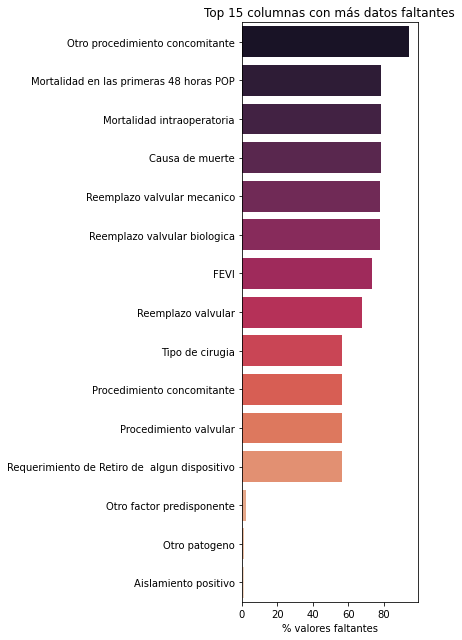

In [28]:
top_missing = missing_by_col[missing_by_col > 0].head(15)
plt.figure(figsize=(6, 9))
sns.barplot(x=top_missing.values, y=top_missing.index, palette="rocket")
plt.xlabel("% valores faltantes")
plt.title("Top 15 columnas con más datos faltantes")
plt.tight_layout()
plt.show()

se observa 12 columnas superan 50% de missing, encabezadas por: Otro procedimiento concomitante (94%), Mortalidad intraoperatoria y Causa de muerte (80% cada una), y Reemplazo valvular mecánico/biológico (~78%).

Algo importante a tener en cuenta es que para el contexto esta perdida de datos es estructural y no aleatoria, **ya que son campos que solo aplican si el paciente fue a cirugía o murió. Por lo cual imputarlos no aplicaria para nuestro flujo de trabajo**

### 3. Estadísticos descriptivos

In [29]:
def iqr_outliers(series):
    s = series.dropna()
    if s.empty:
        return 0, None, None
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((s < low) | (s > high)).sum()
    return n_out, low, high

num_stats = df[numeric_cols].describe().T
num_stats["missing_%"] = df[numeric_cols].isna().mean() * 100
num_stats["outliers_IQR"] = [iqr_outliers(df[c])[0] for c in numeric_cols]
print("\nEstadísticos descriptivos (numéricas):")
print(num_stats.round(2))


Estadísticos descriptivos (numéricas):
                                            count       mean        std  \
Edad                                        140.0      50.19      22.49   
Dias estancia                               140.0      39.87      48.13   
Peso                                        140.0      68.06      24.52   
Presion arterial sistolica                  140.0     116.33      23.50   
Presion arterial diastolica                 140.0      64.42      16.08   
Presion arterial media                      140.0      81.62      16.39   
Frecuencia cardiaca                         140.0      94.54      23.14   
Frecuencia respiratoria                     140.0      20.58       6.00   
Leucocitos                                  139.0   12757.65    6444.80   
Linfocitos                                  139.0    1673.72    2177.17   
Neutrofilos                                 139.0    9662.30    6199.97   
Hemoglobina                                 139.0      10.16

Del análisis de las medidas de tendencia central podemos concluir que la población se mueve en un rango de 0 a 89 años.
La combinación de diversas caracteristicas Leucocitos, Neutrófilos, anemia,creatinina elevada, BUN elevado, frecuencia cardiaca aumentada encajan con manifestaciones frecuentes de la endocarditis infecciosa.

Sin embargo **Estos datos no permiten diagnosticar endocarditis por sí mismos**

tomado de [Infective Endocarditis in High-Income Countries](https://www.mdpi.com/2218-1989/12/8/682).

### Distribuciones para variables numéricas

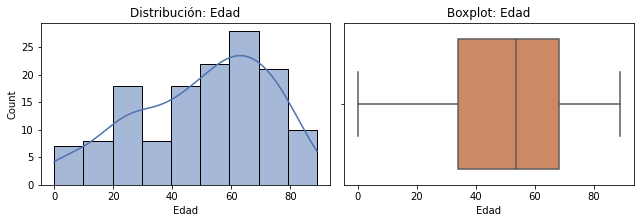

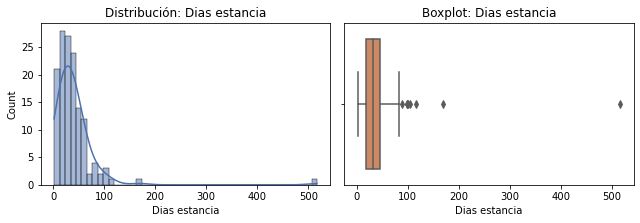

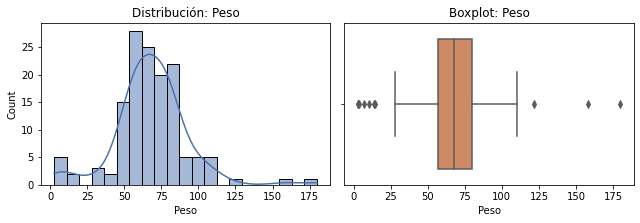

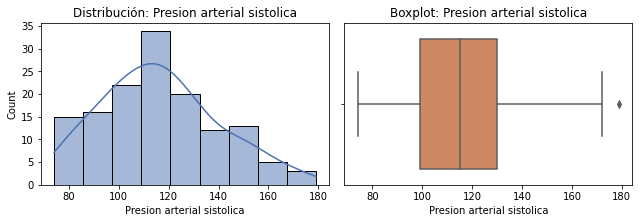

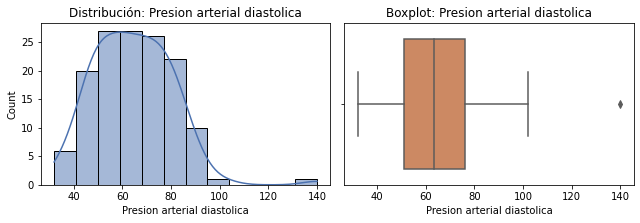

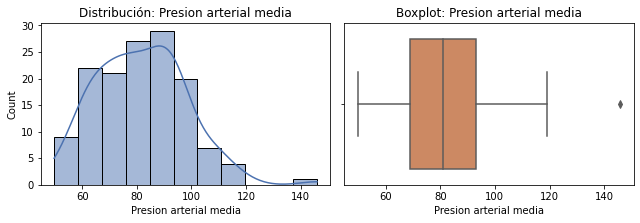

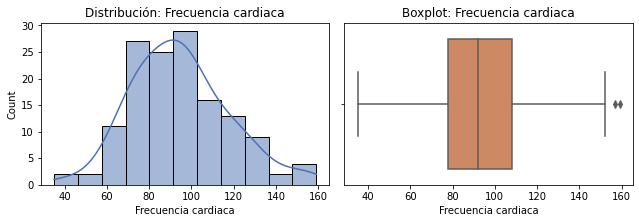

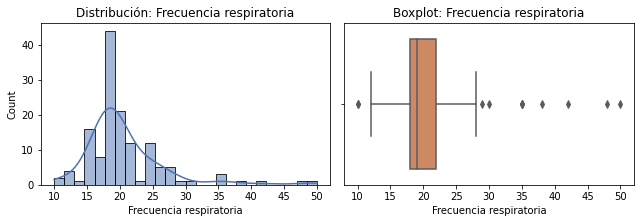

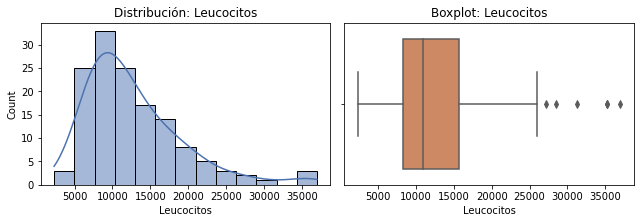

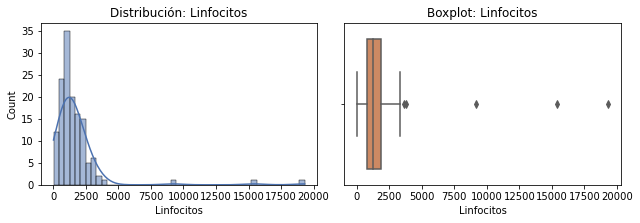

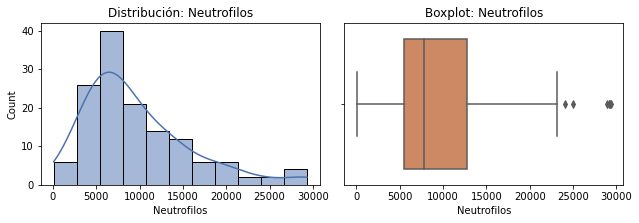

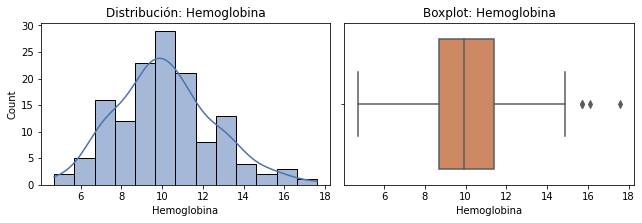

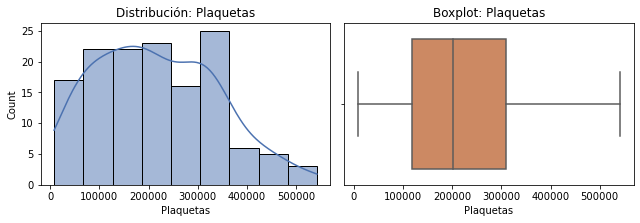

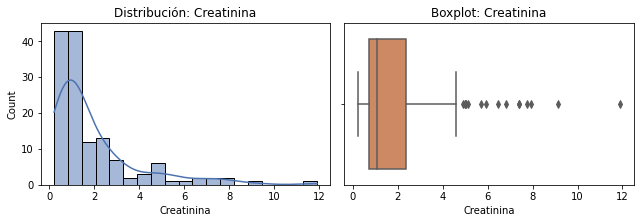

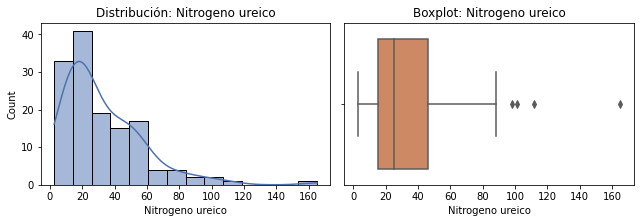

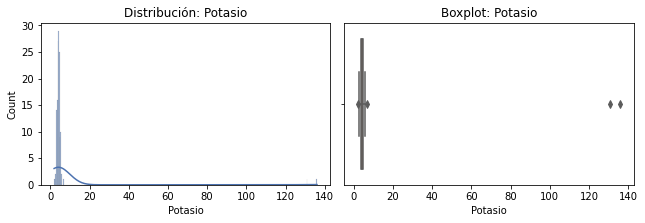

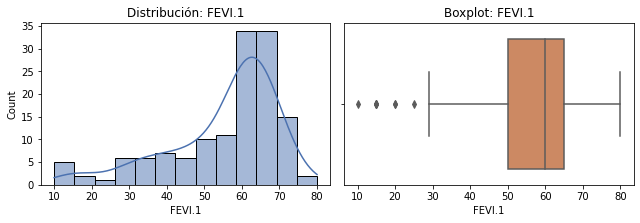

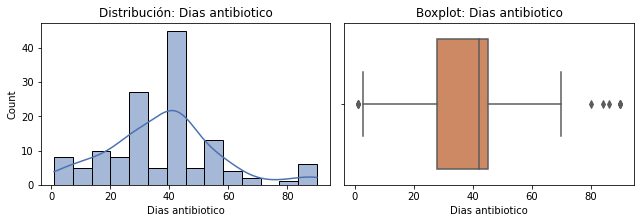

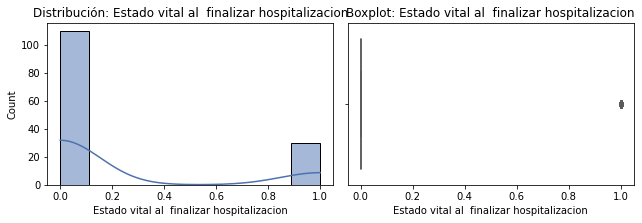

In [30]:
for col in numeric_cols:
    if col == "ID":
        continue
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0], color="#4C72B0")
    axes[0].set_title(f"Distribución: {col}")
    sns.boxplot(x=df[col], ax=axes[1], color="#DD8452")
    axes[1].set_title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()

Se confirma visualmente que la mayoría de laboratorios (leucocitos, PCR, creatinina) tienen distribución sesgada a la derecha (no normal), típico en datos clínicos de infección

Se observan valores atípicos para el valor de (K), que no concuerda con los rango esperados.

**Al tener una distribución no normal se debe o transformar para poder aplicar pruebas parametricas ó aplicar pruebas no paramétricas**

#### SCATTER PLOTS

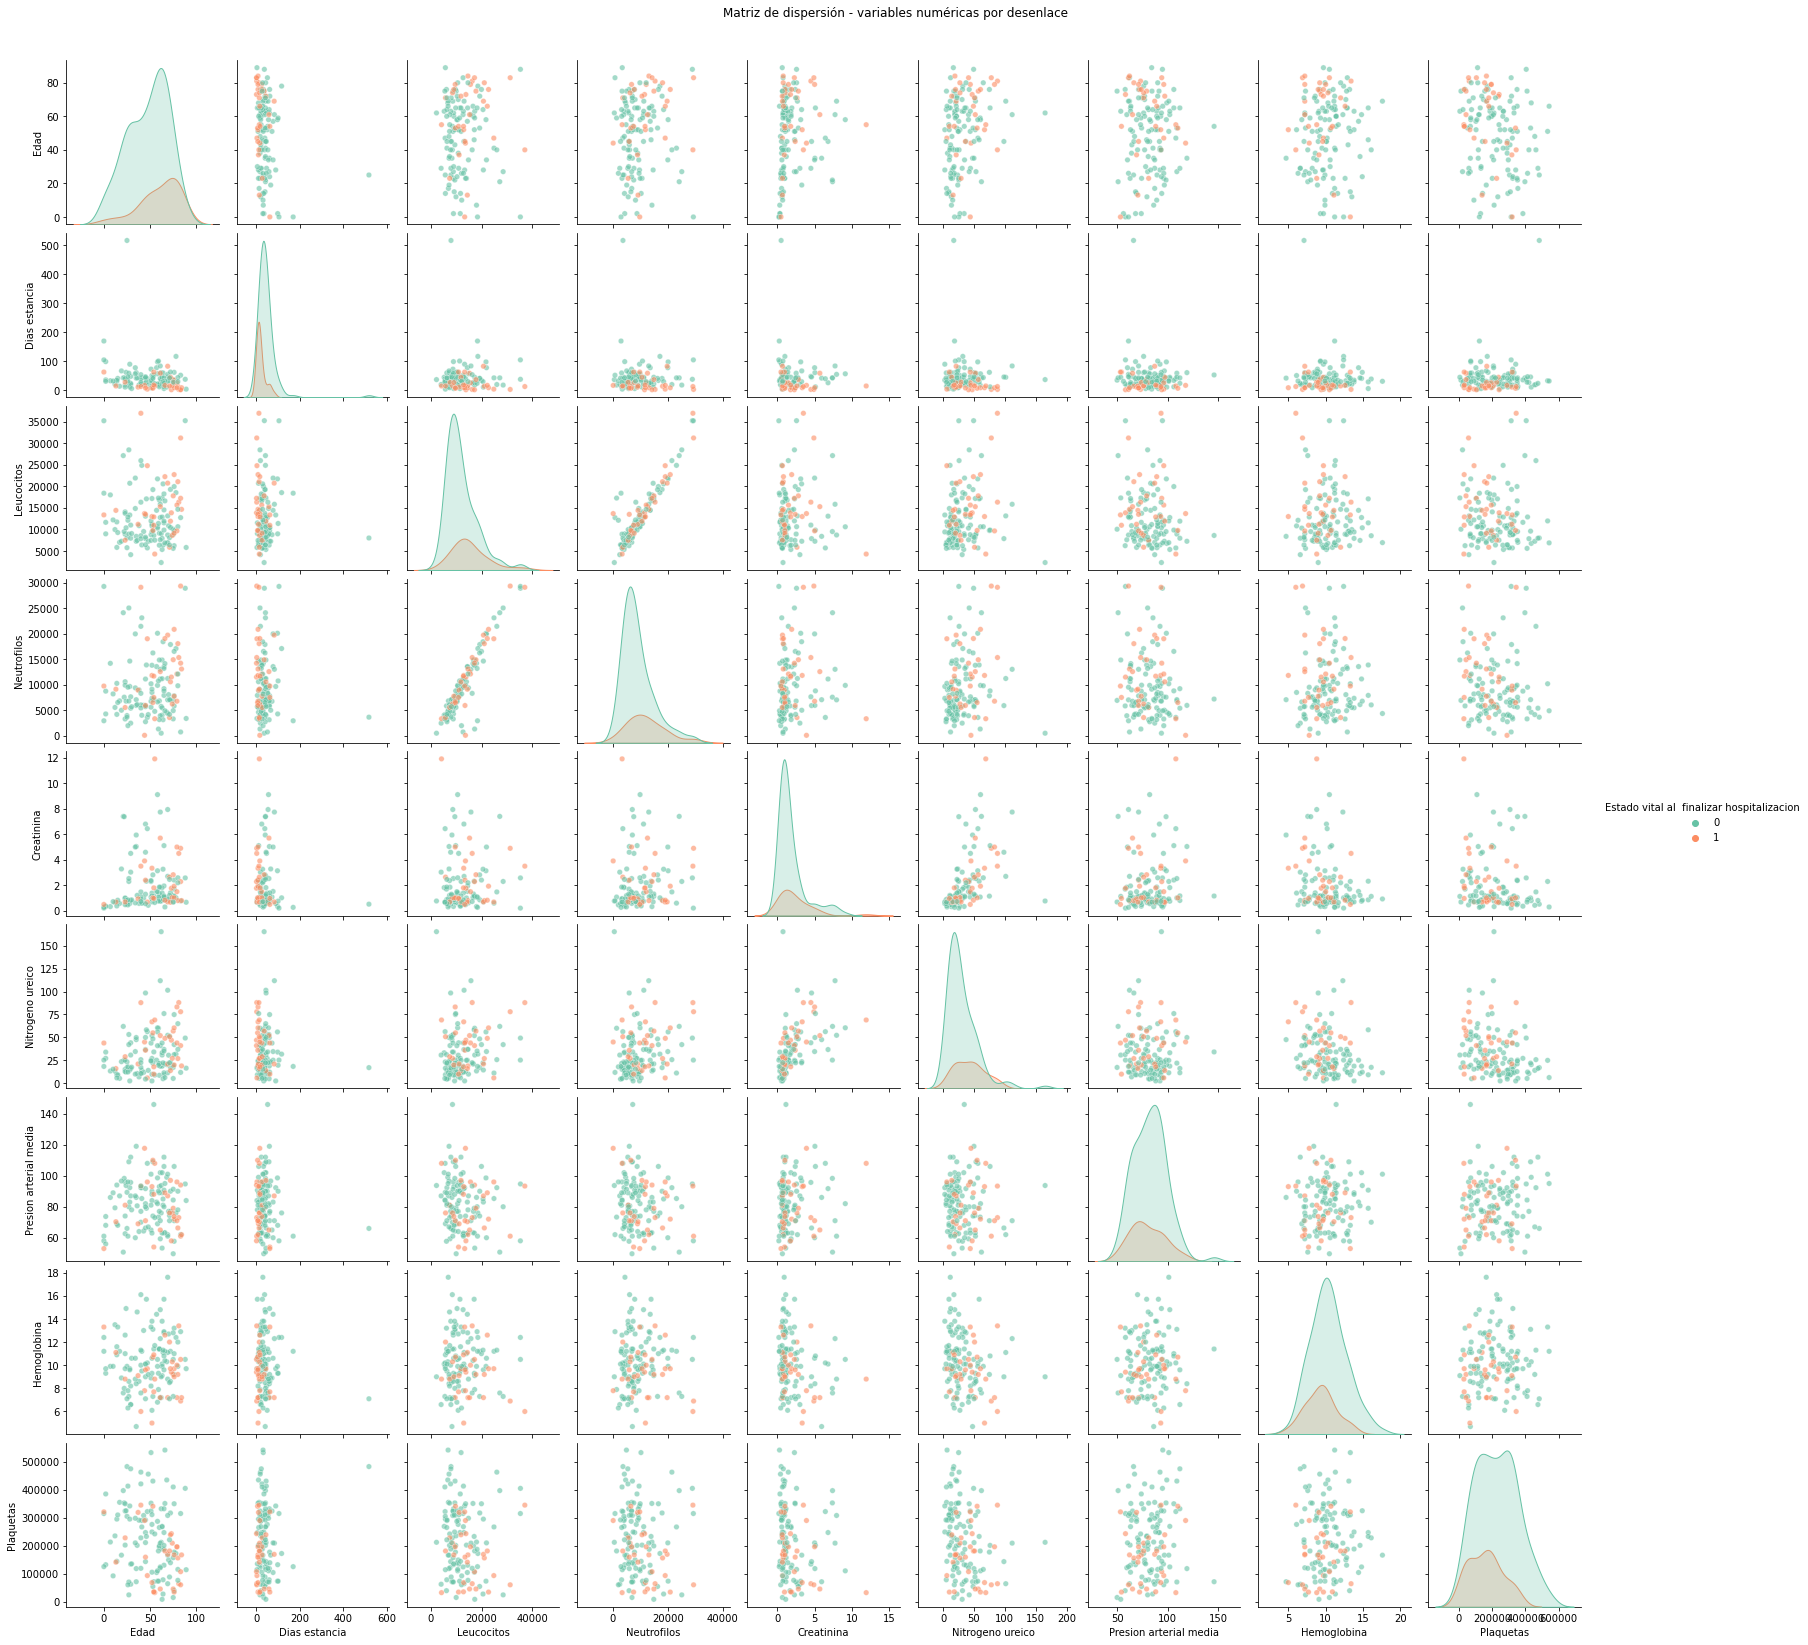

In [31]:
# generamos un pirplot basado en las varíables numéricas mas relevantes
subset_cols = ["Edad", "Dias estancia", "Leucocitos", "Neutrofilos",
               "Creatinina", "Nitrogeno ureico", "Presion arterial media",
               "Hemoglobina", "Plaquetas"]
subset_cols = [c for c in subset_cols if c in df.columns]

target = "Estado vital al  finalizar hospitalizacion"
plot_df = df[subset_cols + [target]].copy()

sns.pairplot(plot_df, hue=target, diag_kind="kde", palette="Set2",
             plot_kws={"alpha": 0.6, "s": 30})
plt.suptitle("Matriz de dispersión - variables numéricas por desenlace", y=1.02)
plt.show()

No aparece ninguna variable numérica aislada que separe claramente a los pacientes que mueren de los que sobreviven, las nubes de puntos de "Muerto" y "Vivo" se solapan bastante en casi todos los pares.

#### Correlación entre variables numéricas

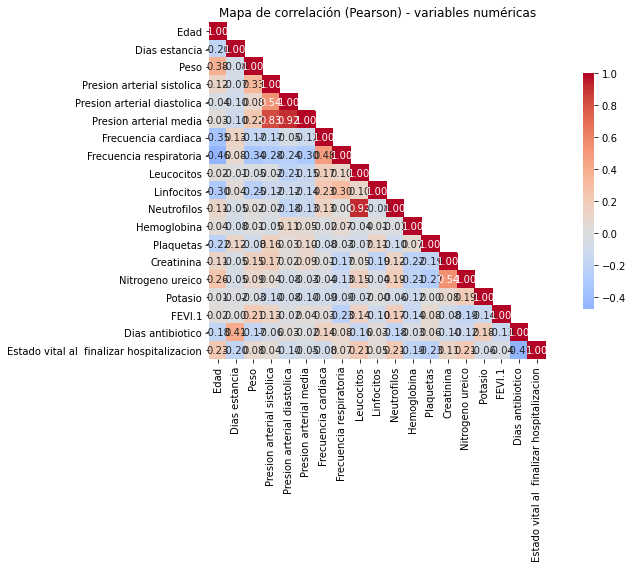

In [33]:
corr_cols = [c for c in numeric_cols if c != "ID"]

# Matriz de correlación
corr = df[corr_cols].corr()

# Máscara para ocultar el triángulo superior
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# Gráfico
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.7}
)

plt.title("Mapa de correlación (Pearson) - variables numéricas")
plt.tight_layout()
plt.show()

Las correlaciones más fuertes esperables son creatinina–nitrógeno ureico (ambas función renal) y leucocitos–neutrófilos (relación fisiológica directa).

Los pares con mayor correlacion son Leucocitos vs Neutrófilos (r=0.92) ,Presión diastólica vs Presión arterial media (r=0.92) y sistólica vs media (r=0.84) que son correlaciones esperedas fisiológicamente

La correlación de edad contra Días de instancias es baja r= -0.19 y no se visualiza claramente un patron que permita diferencar la mortalidad en los pacientes

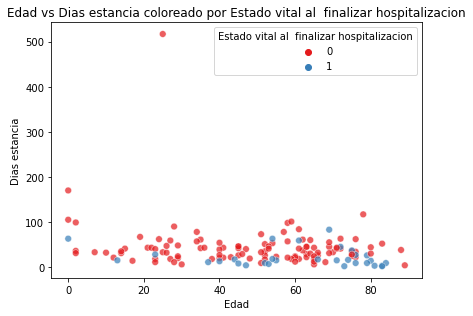

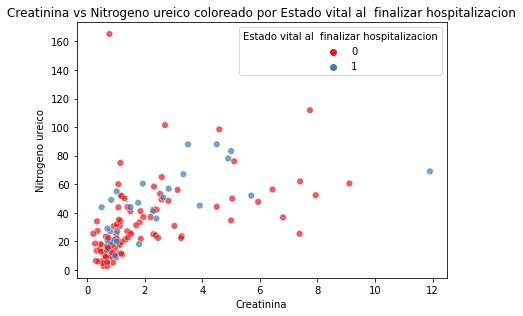

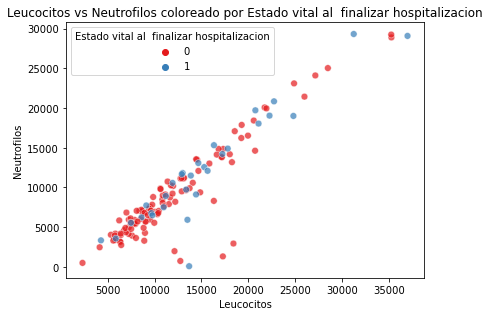

In [34]:
pares_clinicos = [
    ("Edad", "Dias estancia"),
    ("Creatinina", "Nitrogeno ureico"),
    ("Leucocitos", "Neutrofilos"),
]

for x, y in pares_clinicos:
    if x in df.columns and y in df.columns and target in df.columns:
        plt.figure(figsize=(6, 4.5))
        sns.scatterplot(data=df, x=x, y=y, hue=target, palette="Set1",
                         alpha=0.7, s=45)
        plt.title(f"{x} vs {y} coloreado por {target}")
        plt.tight_layout()
        plt.show()

De la graduca de Leucocitos vs Neutrófilos por desenlace podemos observar una colinealidad

#### Análisis categórico


--- Sexo ---
Hombre    94
Mujer     46
Name: Sexo, dtype: int64


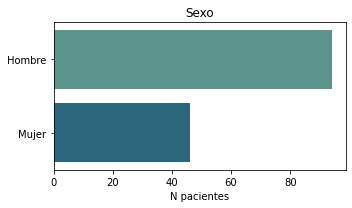


--- Estado vital al  finalizar hospitalizacion ---
0    110
1     30
Name: Estado vital al  finalizar hospitalizacion, dtype: int64


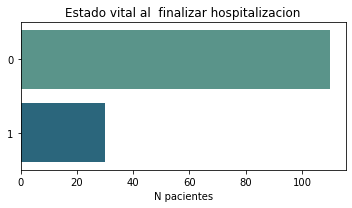


--- Tipo de endocarditis ---
Nativa                            90
Protesica                         30
Asociada a cateter                13
Asociada a Dispositvo cardiaco     5
NaN                                1
No information                     1
Name: Tipo de endocarditis, dtype: int64


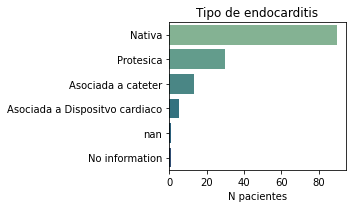


--- Hemocultivo ---
Positivo    124
Negativo     15
NaN           1
Name: Hemocultivo, dtype: int64


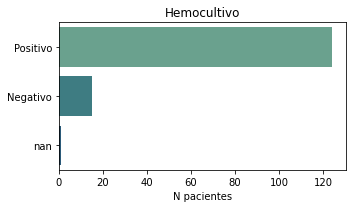


--- Requerimiento de UCI ---
Si     107
No      32
NaN      1
Name: Requerimiento de UCI, dtype: int64


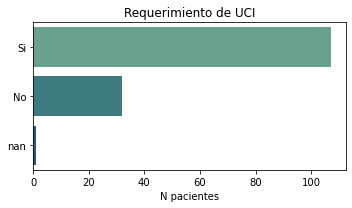


--- Diagnostico con criterios de Duke ---
Definitivo    132
Posible         4
Improbable      3
NaN             1
Name: Diagnostico con criterios de Duke, dtype: int64


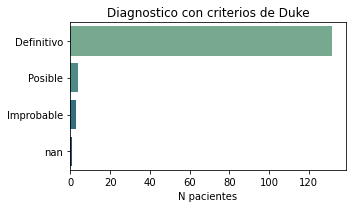


--- Intervencion quirurgica ---
No     78
Si     61
NaN     1
Name: Intervencion quirurgica, dtype: int64


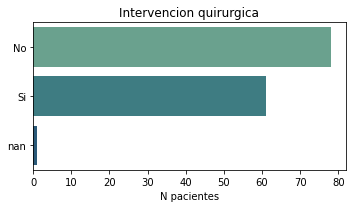


--- Sospecha clinica ---
Si     115
No      24
NaN      1
Name: Sospecha clinica, dtype: int64


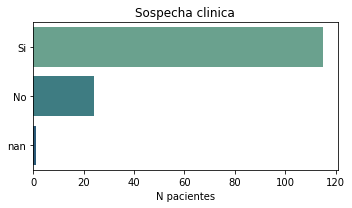

In [35]:
KEY_CATS = [c for c in [
    "Sexo", "Estado vital al  finalizar hospitalizacion", "Tipo de endocarditis",
    "Hemocultivo", "Requerimiento de UCI", "Diagnostico con criterios de Duke",
    "Intervencion quirurgica", "Sospecha clinica"
] if c in df.columns]

for col in KEY_CATS:
    vc = df[col].value_counts(dropna=False)
    print(f"\n--- {col} ---")
    print(vc)

    plt.figure(figsize=(5, 3))
    sns.barplot(x=vc.values, y=vc.index.astype(str), palette="crest")
    plt.title(col)
    plt.xlabel("N pacientes")
    plt.tight_layout()
    plt.show()

Se evidencia una cohorte predominantemente masculina; adicionalmente la mortalidad intrahospitalaria de la corte es aproximadamente el 20%. Y la distribución de tipo de endocarditis es de predominio de valvula nativa.

### Conclusiones del análisis

Se cuenta con una base solida con solo un 4.2% de datos perdidos, que deben ser tratados con cuidado debido a la naturaleza de la información.

No se evidencio ninguna variable numérica aislada (edad, creatinina, leucocitos, etc.) que separe claramente a los pacientes que fallecen de los que sobreviven — las distribuciones se solapan en casi todos los cruces. Las correlaciones más fuertes encontradas (leucocitos-neutrófilos, presión sistólica/diastólica-media) son en su mayoría redundancias fisiológicas o matemáticas, no hallazgos nuevos.

Esto sugiere que el pronóstico de mortalidad en esta cohorte es multifactorial: no va a explicarse con las variables de laboratorio, sino con la combinación de variables categóricas (tipo de germen, complicaciones, necesidad de cirugía/UCI) y numéricas.